<p align="center"><b><font size="6">Transformer-Based Text Generation using FLAN-T5</font></b></p>

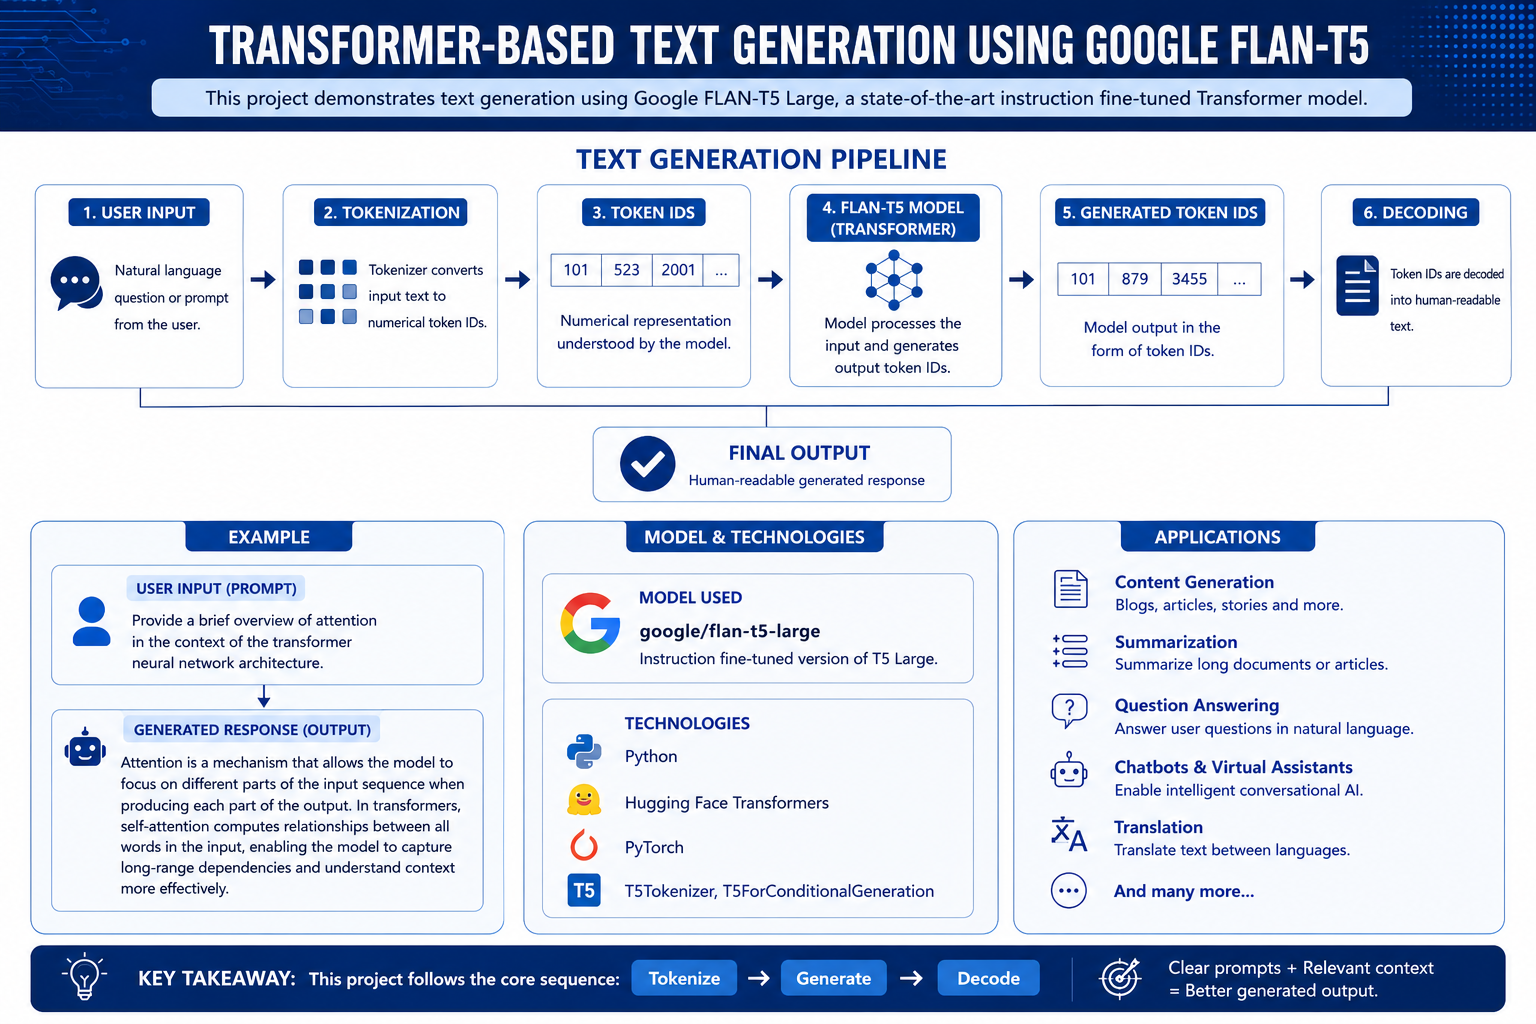

# **Installing and Importing Necessary Libraries**

In [59]:
# installing the transformers library
!pip install transformers -q

In [60]:
# to load transformer models
from transformers import T5Tokenizer, T5ForConditionalGeneration

# to load a Deep Learning library
import torch

# **Generating Text with Transformers**

## **Step 1:** Load the pre-trained model and tokenizer


First, we load the pre-trained model and its tokenizer.

We'll be using the **Google FLAN-T5** model here.

* **FLAN-T5** is a language model developed by **Google Research**, based on the **T5 (Text-to-Text Transfer Transformer)** architecture.
* FLAN stands for **Fine-tuned Language Net**.
* It performs well on many **NLP tasks, such as question answering, translation, summarization, and text generation.**
* It is available in different sizes: Small, Base, Large, XL, and XXL.
* Use cases: Text generation, classification, summarization, sentiment analysis, question answering, translation, and chatbots.

In [61]:

# defining the model name
model_name = "google/flan-t5-large"

# The 'from_pretrained' method allows us to load a pre-trained tokenizer from Hugging Face's model hub.
tokenizer = T5Tokenizer.from_pretrained(model_name)

# Load the pre-trained model for text generation
model = T5ForConditionalGeneration.from_pretrained(model_name)

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


- **`T5Tokenizer`**: Converts text into numbers that the model can understand.
- **`T5ForConditionalGeneration`**: Loads the pretrained model for generating text.

## **Step 2:** Define the input

Next, the input for the model.

In [62]:
input_text = "Explain how to make a chocolate cake."

## **Step 3:** Tokenize the input

Next, we tokenize the input to make it ready to be passed to the model.

In [63]:
# tokenizing the input
input_ids = tokenizer.encode(input_text, return_tensors='pt')

- **`tokenizer.encode()`**: Converts human-readable text into numeric tokens that the model can understand. These tokens can represent words or parts of words.
    - **`input_question`**: the text input for the model.
    - **`return_tensors='pt'`**: Converts the tokenized output into a PyTorch tensor (`'pt'` stands for PyTorch).

Let's check the output of tokenization.

In [64]:
print("Token IDs:", input_ids)

Token IDs: tensor([[25488,   149,    12,   143,     3,     9,  3711,  4340,     5,     1]])


- The input text is broken down into a list of tokens, and the IDs of each token are displayed.

## **Step 4:** Pass tokenized input to the model

Next, we pass the tokenized input to the model for generating outputs.

In [65]:
# generating model output
output_tokens = model.generate(input_ids, max_length=256, num_return_sequences=1)

- **`input_ids`**
  - Tokenized input text

- **`max_length=256`**
  - Sets the **maximum number of tokens** allowed in the generated output.
  - This includes ***both*** the input and output tokens
  - The value can be adjusted based on the **required output length** and the model's maximum limit.

- **`num_return_sequences=1`**
  - Tells the model how many different outputs to generate for the same input.
  - Can be set to more than 1 if multiple variations of the output are required

Let's check the output from the model.

In [66]:
print("Output Tokens:", output_tokens)

Output Tokens: tensor([[    0,  7382,   204, 12294,  7055,     6,   209,  4119, 11530,     9,
             6,   209, 21776,  6506,  4926,     6,   209, 21776,  6506, 12495,
             6,   209, 21776, 13478,     6,   209, 21776,  3136,    11,   209,
         21776, 18684,    16,     3,     9,   508,  3047,     5,  2334,     8,
          4194,    11,  2153,   552,     8,  4989,    19,   659,    11, 25155,
             5,  2334,     8,  5875,    11,  2153,   552,     8,  4989,    19,
          4126,    11, 25155,     5,  1474,     8, 15839,   139,     3,     9,
         19373,    26,    11,  7055,    15,    26,  4340,  2131,     5, 15512,
             8,  4340,    21,  3097,    12,  1283,   676,    42,   552,     3,
             9,  6290, 17967,     3, 19435,    16,     8,  1530,   639,    91,
          1349,     5,  1563,     8,  4340,  1633,    16,     8,  2131,    21,
           335,   676,     5,     1]])


- As we can see, the model output is a list of token IDs.

## **Step 5:** Decode the generated output

Finally, we decode the model's output token IDs to obtain a human-readable text.

In [67]:
# decode the generated output from token IDs to human-readable text
# 'skip_special_tokens=True' ensures that special tokens are omitted from the decoded output
generated_text = tokenizer.decode(output_tokens[0], skip_special_tokens=True)

In [68]:
print("Generated Text: ", generated_text)

Generated Text:  Mix 2 cups flour, 1 cup cocoa, 1 teaspoon baking powder, 1 teaspoon baking soda, 1 teaspoon vanilla, 1 teaspoon salt and 1 teaspoon cinnamon in a large bowl. Add the butter and mix until the mixture is light and fluffy. Add the eggs and mix until the mixture is thick and fluffy. Pour the batter into a greased and floured cake pan. Bake the cake for 35 to 40 minutes or until a toothpick inserted in the center comes out clean. Let the cake cool in the pan for 10 minutes.


- As we can see, the model has listed out the steps involved in preparing the healthy breakfast.

**Note**: Given the probabilistic nature of transformers, the output might vary with multiple executions.

## **Stitching Everything Together**

To make the process **reusable and efficient**, we encapsulate the entire sequence of operations above into a function. This function will

1. Take an input text
2. Perform necessary processing
3. Generate the output
3. Return a human-readable response

In [69]:
def generate_response(input, max_length=256, num_return_sequences=1):
    """
    Generates a text response to a given question using a language model.

    Parameters:
    - question (str): The input text for the model.
    - max_length (int): Maximum length of the model's generated response, including the input text.
    - num_return_sequences (int): Number of different responses to generate for the same input.

    Returns:
    - str: The generated text response.
    """
    # checking for GPU availability
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Encode the input question into token IDs
    input_ids = tokenizer(input, return_tensors='pt').input_ids.to(device)

    # Generate the output tokens from the model
    output_tokens = model.generate(input_ids, max_length=max_length, num_return_sequences=num_return_sequences)

    # Decode the generated tokens into human-readable text
    responses = []

    # Iterate over all responses generated, decode them one at a time, and then add them to the response list
    for generated_sequence in output_tokens:
        generated_text = tokenizer.decode(generated_sequence, skip_special_tokens=True)
        responses.append(generated_text)

    return responses

Let's test our function.

In [70]:
input_text = "List the steps to prepare a healthy breakfast."
response = generate_response(input_text, max_length=300)

print(f"Question: {input_text}")
print(f"Response: {response[0]}")

Question: List the steps to prepare a healthy breakfast.
Response: To prepare a healthy breakfast, you need to: Choose a healthy breakfast. Choose a healthy breakfast.


# **More Examples**

**Let's take a look at a few more examples.**

In [71]:
input_text = "What is the capital of India?"
response = generate_response(input_text)

print(f"Question: {input_text}")
print(f"Response: {response[0]}")

Question: What is the capital of India?
Response: calcutta


- The model provided a crisp and correct answer.

In [72]:
input_text = "What is the purpose of a database?"
response = generate_response(input_text)

print(f"Question: {input_text}")
print(f"Response: {response[0]}")

Question: What is the purpose of a database?
Response: to store information


- Again, the model output is crisp and to the point.

In [73]:
input_text = "Provide a brief overview of attention."
response = generate_response(input_text)

print(f"Question: {input_text}")
print(f"Response: {response[0]}")

Question: Provide a brief overview of attention.
Response: Attention is the ability of a person to focus attention on a particular stimulus.


- The model's output is **factually correct**, but it is **not related to the attention mechanism in Transformers**.
This happens because **the input did not specify** the required context.
The model can generate text, but it **cannot infer the expected context implicitly**.
Therefore, we should provide **clear and specific prompts?** to get the desired output.

In [74]:
input_text = "Provide a brief overview of attention in the context of the transformer neural network architecture."
response = generate_response(input_text)

print(f"Question: {input_text}")
print(f"Response: {response[0]}")

Question: Provide a brief overview of attention in the context of the transformer neural network architecture.
Response: Attention is the ability to focus attention on a particular stimulus or object. The Transformer architecture uses a transformer architecture to achieve this goal.


- The output provides a **basic overview** of the attention mechanism in Transformers, but some parts are **unclear or incorrect**.
- This may happen because the **model was not trained on sufficient data related to the given input**.
- To improve the response, we need to **provide more context and specific instructions** to the model.

In [75]:
input_text = """
The attention mechanism in transformers is a technique that enables models to assign weights to the importance of different tokens in a sequence when embedding or generating text.
Instead of processing the input sequentially one token at a time, attention allows the model to consider all tokens simultaneously by focusing on relevant parts of the input.
It computes attention scores based on the relationships between tokens, which helps identify contextual dependencies. This results in an improved understanding of language context and meaning.
Self-attention assesses connections within the input sequence and multi-head attention allows the model to capture diverse relationships by using multiple attention heads simultaneously.

Based on the above information, provide a brief overview of attention in the context of the transformer neural network architecture.
"""
response = generate_response(input_text)

print(f"Question: {input_text}")
print(f"Response: {response[0]}")

Question: 
The attention mechanism in transformers is a technique that enables models to assign weights to the importance of different tokens in a sequence when embedding or generating text.
Instead of processing the input sequentially one token at a time, attention allows the model to consider all tokens simultaneously by focusing on relevant parts of the input.
It computes attention scores based on the relationships between tokens, which helps identify contextual dependencies. This results in an improved understanding of language context and meaning.
Self-attention assesses connections within the input sequence and multi-head attention allows the model to capture diverse relationships by using multiple attention heads simultaneously.

Based on the above information, provide a brief overview of attention in the context of the transformer neural network architecture.

Response: The attention mechanism in transformers is a technique that enables models to assign weights to the importanc

- Given more context, the model was able to generate a more accurate and desired output.

# **Conclusion**

We learned how to use Transformers for text generation.
- The input text is first **tokenized** and then passed to the model.
- The model generates an output, which is then **decoded into human-readable text**.
- Parameters like `max_length` allow us to control the **maximum length of the generated output**.

# **Future Improvements**

*   **Explore different FLAN-T5 sizes:** Experiment with `flan-t5-small`, `flan-t5-base`, `flan-t5-xl`, or `flan-t5-xxl` to observe the trade-offs between model size, performance, and inference speed.

*   **Fine-tuning:** Consider fine-tuning the FLAN-T5 model on a custom dataset tailored to a specific domain or task to improve its performance for specialized applications.

*   **Evaluation Metrics:** Implement quantitative evaluation metrics (e.g., ROUGE, BLEU) to objectively measure the quality of the generated text, rather than relying solely on qualitative assessment.

*   **Prompt Engineering:** Explore more advanced prompt engineering techniques, such as few-shot learning or instruction tuning, to guide the model towards generating more accurate and relevant responses.

*   **Integrate with a UI:** Build a simple web interface or chatbot integration to allow users to interact with the model more easily.

*   **Batch Processing:** For efficiency, implement batch processing of inputs, especially when dealing with multiple text generation requests.

<font size=6 color='navyblue'>Power Ahead!</font>
___